In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score, roc_auc_score, roc_curve

In [2]:
df = pd.read_csv("Loan_Default_noisy.csv")
df

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019.0,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,746.215017,CIB,25-34,NaN,100.626765,south,direct,1,44.316903
1,24891,2019.0,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,554.238912,EXP,55-64,to_inst,NaN,North,Indriect,1,NaN
2,24892,2019.0,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,840.588714,CIB,35-44,to_inst,83.705329,south,direct,0,46.122815
3,24893,2019.0,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,584.777172,CIB,45-54,not_inst,68.882168,North,direct,0,42.106659
4,24894,2019.0,ncf,Female,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602.688123,EXP,25-34,not_inst,90.095035,North,direct,0,39.285141
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148665,173555,2019.0,cf,Sex Not Available,nopre,type1,p3,l1,nopc,nob/c,...,CIB,652.155358,EXP,55-64,to_inst,68.666910,south,direct,0,48.166442
148666,173556,2019.0,cf,Male,nopre,type1,p1,l1,nopc,nob/c,...,CIB,573.106519,CIB,25-34,not_inst,76.059092,south,direct,0,14.065670
148667,173557,2019.0,cf,Male,nopre,type1,p4,l1,nopc,NaN,...,CIB,694.363727,EXP,45-54,not_inst,61.354485,North,direct,0,48.000243
148668,173558,2019.0,cf,Female,nopre,type1,p4,l1,nopc,nob/c,...,EXP,737.446770,EXP,55-64,to_inst,67.125686,North,direct,0,28.484145


In [3]:
df.isnull().sum()

ID                               0
year                          2973
loan_limit                    6075
Gender                        2973
approv_in_adv                 3834
loan_type                     2973
loan_purpose                  3094
Credit_Worthiness             2973
open_credit                   2973
business_or_commercial        2973
loan_amount                   2973
rate_of_interest             38659
Interest_rate_spread         38895
Upfront_charges              41852
term                          3014
Neg_ammortization             3079
interest_only                 2973
lump_sum_payment              2973
property_value               17767
construction_type             2973
occupancy_type                2973
Secured_by                    2973
total_units                   2973
income                       11926
credit_type                   2973
Credit_Score                  2973
co-applicant_credit_type      2973
age                           3163
submission_of_applic

In [4]:
df.fillna(df.mean(numeric_only=True), inplace=True)

df.fillna(df.mode().iloc[0], inplace=True)

In [5]:
df.isnull().sum()

ID                           0
year                         0
loan_limit                   0
Gender                       0
approv_in_adv                0
loan_type                    0
loan_purpose                 0
Credit_Worthiness            0
open_credit                  0
business_or_commercial       0
loan_amount                  0
rate_of_interest             0
Interest_rate_spread         0
Upfront_charges              0
term                         0
Neg_ammortization            0
interest_only                0
lump_sum_payment             0
property_value               0
construction_type            0
occupancy_type               0
Secured_by                   0
total_units                  0
income                       0
credit_type                  0
Credit_Score                 0
co-applicant_credit_type     0
age                          0
submission_of_application    0
LTV                          0
Region                       0
Security_Type                0
Status  

In [6]:
X = df.drop(["Status", "ID"], axis=1)
y = df["Status"]

In [7]:
X

,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,...,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,dtir1
0,2019.0,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,121067.517861,...,1858.457300,EXP,746.215017,CIB,25-34,to_inst,100.626765,south,direct,44.316903
1,2019.0,cf,Male,nopre,type2,p1,l1,nopc,b/c,205228.595388,...,4900.585983,EQUI,554.238912,EXP,55-64,to_inst,72.749487,North,Indriect,37.729478
2,2019.0,cf,Male,pre,type1,p1,l1,nopc,nob/c,412455.797611,...,9767.290923,EXP,840.588714,CIB,35-44,to_inst,83.705329,south,direct,46.122815
3,2019.0,cf,Male,nopre,type1,p4,l1,nopc,nob/c,470504.968510,...,12147.503090,EXP,584.777172,CIB,45-54,not_inst,68.882168,North,direct,42.106659
4,2019.0,ncf,Female,pre,type1,p1,l1,nopc,nob/c,694346.850720,...,10170.661263,CRIF,602.688123,EXP,25-34,not_inst,90.095035,North,direct,39.285141
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148665,2019.0,cf,Sex Not Available,nopre,type1,p3,l1,nopc,nob/c,427282.458248,...,7392.683033,CIB,652.155358,EXP,55-64,to_inst,68.666910,south,direct,48.166442
148666,2019.0,cf,Male,nopre,type1,p1,l1,nopc,nob/c,576099.550521,...,7538.642963,CIB,573.106519,CIB,25-34,not_inst,76.059092,south,direct,14.065670
148667,2019.0,cf,Male,nopre,type1,p4,l1,nopc,nob/c,449240.868098,...,7285.257310,CIB,694.363727,EXP,45-54,not_inst,61.354485,North,direct,48.000243
148668,2019.0,cf,Female,nopre,type1,p4,l1,nopc,nob/c,201055.514288,...,7349.968371,EXP,737.446770,EXP,55-64,to_inst,67.125686,North,direct,28.484145


In [8]:
y

0         1
1         1
2         0
3         0
4         0
         ..
148665    0
148666    0
148667    0
148668    0
148669    0
Name: Status, Length: 148670, dtype: int64

In [9]:
import warnings
warnings.filterwarnings("ignore")

In [10]:
print(df.select_dtypes(include='object').columns)

Index(['loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose',
       'Credit_Worthiness', 'open_credit', 'business_or_commercial',
       'Neg_ammortization', 'interest_only', 'lump_sum_payment',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'credit_type', 'co-applicant_credit_type', 'age',
       'submission_of_application', 'Region', 'Security_Type'],
      dtype='object')


In [11]:
from imblearn.over_sampling import RandomOverSampler

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
print(X.select_dtypes(include='object').columns)

Index(['loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose',
       'Credit_Worthiness', 'open_credit', 'business_or_commercial',
       'Neg_ammortization', 'interest_only', 'lump_sum_payment',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'credit_type', 'co-applicant_credit_type', 'age',
       'submission_of_application', 'Region', 'Security_Type'],
      dtype='object')


In [14]:
X = pd.get_dummies(X, drop_first=True)
X

,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,...,age_45-54,age_55-64,age_65-74,age_<25,age_>74,submission_of_application_to_inst,Region_North-East,Region_central,Region_south,Security_Type_direct
0,2019.0,121067.517861,4.045353,0.441512,3223.441069,362.511374,145408.197575,1858.457300,746.215017,100.626765,...,False,False,False,False,False,True,False,False,True,True
1,2019.0,205228.595388,4.045353,0.441512,3223.441069,359.814697,497684.788769,4900.585983,554.238912,72.749487,...,False,True,False,False,False,True,False,False,False,False
2,2019.0,412455.797611,4.554806,0.177479,818.203219,357.929452,501092.762356,9767.290923,840.588714,83.705329,...,False,False,False,False,False,True,False,False,True,True
3,2019.0,470504.968510,4.253182,0.676191,3223.441069,335.113870,639569.873705,12147.503090,584.777172,68.882168,...,True,False,False,False,False,False,False,False,False,True
4,2019.0,694346.850720,3.969755,0.319922,-19.579978,360.806190,749573.923075,10170.661263,602.688123,90.095035,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148665,2019.0,427282.458248,3.120790,0.245775,9844.996842,176.732287,574886.831963,7392.683033,652.155358,68.666910,...,False,True,False,False,False,True,False,False,True,True
148666,2019.0,576099.550521,5.218606,0.830088,332.330271,362.069505,793169.433938,7538.642963,573.106519,76.059092,...,False,False,False,False,False,False,False,False,True,True
148667,2019.0,449240.868098,3.146807,0.083314,1414.991524,177.069862,741080.198032,7285.257310,694.363727,61.354485,...,True,False,False,False,False,False,False,False,False,True
148668,2019.0,201055.514288,4.045353,0.609147,4408.403108,184.255311,273425.689972,7349.968371,737.446770,67.125686,...,False,True,False,False,False,True,False,False,False,True


In [15]:
print(X.select_dtypes(include='object').columns)

Index([], dtype='object')


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [17]:
	
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

print("Training set after oversampling:", y_train_res.value_counts())

Training set after oversampling: Status
1    78344
0    78344
Name: count, dtype: int64


In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res) 
X_test_scaled = scaler.transform(X_test)

In [19]:
X_train

,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,...,age_45-54,age_55-64,age_65-74,age_<25,age_>74,submission_of_application_to_inst,Region_North-East,Region_central,Region_south,Security_Type_direct
94400,2019.0,435872.517999,4.045353,0.441512,3223.441069,351.998576,497684.788769,7006.950616,824.426119,72.749487,...,True,False,False,False,False,True,False,False,False,True
45735,2019.0,248149.481089,3.584683,0.448136,88.807748,236.421788,333650.516800,7634.800899,516.259317,75.646941,...,False,False,False,False,False,True,False,False,False,True
115209,2019.0,162417.189066,4.045353,0.441512,3223.441069,219.017739,208585.615816,2613.451811,616.712090,75.474059,...,False,True,False,False,False,True,False,False,True,True
133100,2019.0,158055.499892,4.045353,0.441512,3223.441069,357.298245,497684.788769,2890.565672,515.760947,72.749487,...,True,False,False,False,False,True,False,False,True,True
95942,2019.0,77644.361805,4.377930,1.448165,1296.056761,177.640752,99674.339073,5604.318315,635.747270,81.801119,...,False,True,False,False,False,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119879,2019.0,116443.506129,4.045353,0.441512,3223.441069,358.674583,172722.265416,1438.754383,549.378039,67.746631,...,True,False,False,False,False,True,False,False,False,True
103694,2019.0,418989.055747,4.526073,1.325877,36.905689,361.669667,485440.249753,7872.577508,542.221482,85.517688,...,True,False,False,False,False,True,False,True,False,True
131932,2019.0,231847.014632,5.019594,1.329626,5127.675536,354.456061,327752.301409,4870.250996,672.348862,79.061422,...,False,True,False,False,False,True,False,False,True,True
146867,2019.0,331086.160571,3.468607,-0.152723,721.591868,364.148056,980517.657771,10759.291916,514.220356,36.432575,...,True,False,False,False,False,False,False,False,False,True


In [20]:
X_test

,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,...,age_45-54,age_55-64,age_65-74,age_<25,age_>74,submission_of_application_to_inst,Region_North-East,Region_central,Region_south,Security_Type_direct
24912,2019.0,114445.517163,4.973864,1.454877,2481.045045,361.921919,129636.919144,1773.210869,683.209982,81.621151,...,True,False,False,False,False,True,False,False,False,True
147068,2019.0,237076.080175,4.039374,0.435847,2415.244118,361.539399,224284.330515,6100.981303,863.967499,91.541093,...,False,False,False,False,False,True,False,False,True,True
123284,2019.0,128125.151713,3.981608,0.467703,3438.755903,348.532821,715632.097683,2638.321819,602.586946,16.269799,...,False,False,True,False,False,True,False,False,True,True
53610,2019.0,261636.277537,4.272097,0.596380,3480.197414,182.972653,662965.812424,5663.640674,781.042273,38.422562,...,False,False,True,False,False,True,False,False,False,True
39672,2019.0,682331.448012,3.371323,-0.182978,-159.665667,363.368880,834042.013175,6697.286924,648.793023,83.271368,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21982,2019.0,81811.098787,3.244715,1.076546,2953.684353,179.624344,141648.395207,1539.148114,571.723621,58.153204,...,False,False,True,False,False,True,False,False,True,True
56870,2019.0,478188.872114,3.390975,-0.110138,124.330672,360.088694,601848.631995,11299.636692,749.478522,85.004890,...,False,False,False,False,False,False,False,False,False,True
139107,2019.0,274797.648374,4.995679,0.373032,-101.480954,359.562371,483109.381337,3104.752306,528.486315,60.166137,...,False,True,False,False,False,False,False,True,False,True
106213,2019.0,421696.590607,4.986003,1.012354,3427.703924,363.988290,497684.788769,9838.776077,556.741911,79.212721,...,False,False,False,False,False,True,False,False,True,True


In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score

In [22]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train_res)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [23]:
from sklearn.svm import LinearSVC

model = LinearSVC()
model.fit(X_train_scaled, y_train_res)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [24]:
from sklearn.ensemble import RandomForestClassifier 
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_res, y_train_res)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [25]:
svm_model = SVC(kernel='rbf', probability=True) 
svm_model.fit(X_train_scaled, y_train_res) 

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [26]:
from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix, 
    f1_score, 
    roc_auc_score, 
    recall_score, 
    roc_curve, 
    ConfusionMatrixDisplay
)

In [27]:
y_pred_svm_rbf = svm_model.predict(X_test_scaled)
print("SVM RBF Accuracy:", accuracy_score(y_test, y_pred_svm_rbf))

SVM RBF Accuracy: 0.9386112419004058


In [28]:
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.9998878948902491


In [29]:
y_pred_knn = knn_model.predict(X_test_scaled)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy:", accuracy_knn)

KNN Accuracy: 0.7795565121858254


In [30]:
y_pred_svm = model.predict(X_test_scaled)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", accuracy_svm)

SVM Accuracy: 0.8102284702136724


In [31]:
print("SVM Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("\nKNN Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("RF Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("SVM RBF Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm_rbf))

SVM Confusion Matrix:
 [[29475  4212]
 [ 4252  6662]]

KNN Confusion Matrix:
 [[25625  8062]
 [ 1770  9144]]
RF Confusion Matrix:
 [[33685     2]
 [    3 10911]]
SVM RBF Confusion Matrix:
 [[31075  2612]
 [  126 10788]]


In [32]:
print("SVM F1 Score:", f1_score(y_test, y_pred_svm))
print("KNN F1 Score:", f1_score(y_test, y_pred_knn))
print("RF F1 Score:", f1_score(y_test, y_pred_rf))
print("SVM RBF F1 Score:", f1_score(y_test, y_pred_svm_rbf))

SVM F1 Score: 0.6115292821736735
KNN F1 Score: 0.6503556187766714
RF F1 Score: 0.9997709259174417
SVM RBF F1 Score: 0.8873899810808588


In [33]:
print("SVM ROC-AUC:", roc_auc_score(y_test, y_pred_svm))
print("KNN ROC-AUC:", roc_auc_score(y_test, y_pred_knn))
print("RF ROC-AUC:", roc_auc_score(y_test, y_pred_rf))
print("SVM RBF ROC-AUC:", roc_auc_score(y_test, y_pred_svm_rbf))

SVM ROC-AUC: 0.742687626884582
KNN ROC-AUC: 0.7992510867067103
RF ROC-AUC: 0.9998328768054613
SVM RBF ROC-AUC: 0.955458933111115


In [34]:
from sklearn.metrics import recall_score

print("Recall (Defaulter Detection Rate):")
print("KNN Recall:", recall_score(y_test, y_pred_knn))
print("SVM Recall:", recall_score(y_test, y_pred_svm))
print("RF Recall:", recall_score(y_test, y_pred_rf))
print("SVM RBF Recall:", recall_score(y_test, y_pred_svm_rbf))

Recall (Defaulter Detection Rate):
KNN Recall: 0.8378229796591534
SVM Recall: 0.6104086494410849
RF Recall: 0.9997251236943375
SVM RBF Recall: 0.9884551951621771


In [35]:
import pandas as pd

models_info = [
    {"Model": "Linear SVM", "Parameters": f"C={model.C}, Max Iter={model.max_iter}"},
    {"Model": "KNN", "Parameters": f"n_neighbors={knn_model.n_neighbors}, weights='{knn_model.weights}'"},
    {"Model": "Random Forest", "Parameters": f"n_estimators={rf_model.n_estimators}, max_depth={rf_model.max_depth}"},
    {"Model": "SVM RBF", "Parameters": f"C={svm_model.C}, kernel='{svm_model.kernel}', gamma='{svm_model.gamma}'"}
]

df_params_clean = pd.DataFrame(models_info)
df_params_clean

,Model,Parameters
0,Linear SVM,"C=1.0, Max Iter=1000"
1,KNN,"n_neighbors=5, weights='uniform'"
2,Random Forest,"n_estimators=100, max_depth=None"
3,SVM RBF,"C=1.0, kernel='rbf', gamma='scale'"


In [36]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, recall_score

evaluation_data = [
    {
        "Model": "Linear SVM",
        "Accuracy": accuracy_score(y_test, y_pred_svm),
        "F1-Score": f1_score(y_test, y_pred_svm),
        "ROC-AUC": roc_auc_score(y_test, y_pred_svm),
        "Recall": recall_score(y_test, y_pred_svm),
        "Parameters": f"C={model.C}, Max Iter={model.max_iter}"
    },
    {
        "Model": "KNN",
        "Accuracy": accuracy_score(y_test, y_pred_knn),
        "F1-Score": f1_score(y_test, y_pred_knn),
        "ROC-AUC": roc_auc_score(y_test, y_pred_knn),
        "Recall": recall_score(y_test, y_pred_knn),
        "Parameters": f"n_neighbors={knn_model.n_neighbors}, weights='{knn_model.weights}'"
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "F1-Score": f1_score(y_test, y_pred_rf),
        "ROC-AUC": roc_auc_score(y_test, y_pred_rf),
        "Recall": recall_score(y_test, y_pred_rf),
        "Parameters": f"n_estimators={rf_model.n_estimators}, max_depth={rf_model.max_depth}"
    },
    {
        "Model": "SVM RBF",
        "Accuracy": accuracy_score(y_test, y_pred_svm_rbf),
        "F1-Score": f1_score(y_test, y_pred_svm_rbf),
        "ROC-AUC": roc_auc_score(y_test, y_pred_svm_rbf),
        "Recall": recall_score(y_test, y_pred_svm_rbf),
        "Parameters": f"C={svm_model.C}, kernel='{svm_model.kernel}'"
    }
]

df_report = pd.DataFrame(evaluation_data)
df_report

,Model,Accuracy,F1-Score,ROC-AUC,Recall,Parameters
0,Linear SVM,0.810228,0.611529,0.742688,0.610409,"C=1.0, Max Iter=1000"
1,KNN,0.779557,0.650356,0.799251,0.837823,"n_neighbors=5, weights='uniform'"
2,Random Forest,0.999888,0.999771,0.999833,0.999725,"n_estimators=100, max_depth=None"
3,SVM RBF,0.938611,0.887390,0.955459,0.988455,"C=1.0, kernel='rbf'"


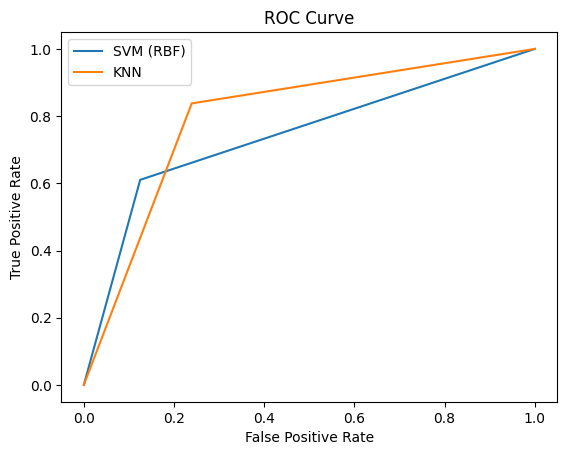

In [37]:
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_pred_svm)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_pred_knn)

plt.plot(fpr_svm, tpr_svm, label="SVM (RBF)")
plt.plot(fpr_knn, tpr_knn, label="KNN")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

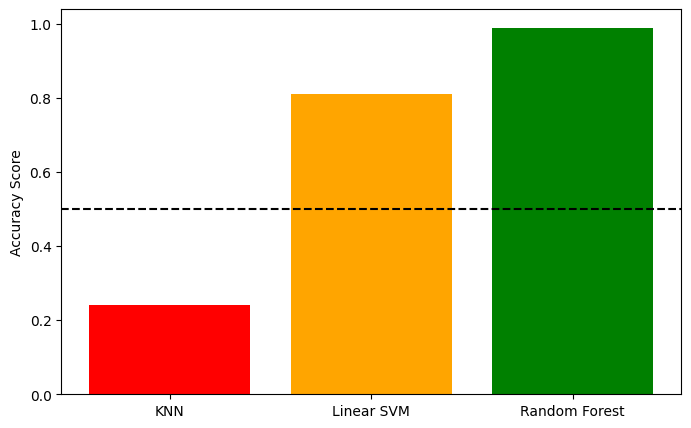

In [63]:
import matplotlib.pyplot as plt

models = ['KNN', 'Linear SVM', 'Random Forest']
accuracies = [0.24, 0.81, 0.99]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=['red', 'orange', 'green'])
plt.axhline(y=0.5, color='black', linestyle='--')
plt.ylabel("Accuracy Score")
plt.show()

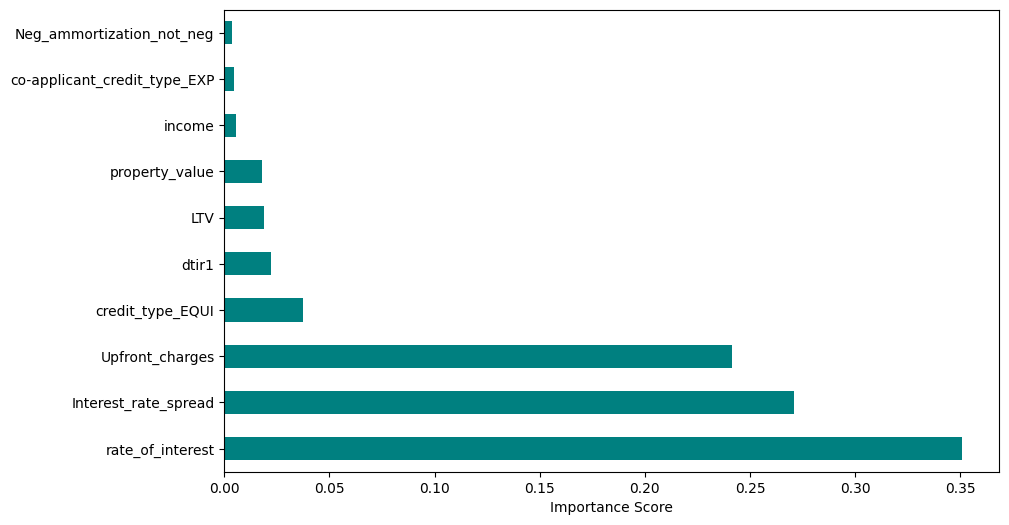

In [64]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
plt.figure(figsize=(10, 6))
importances.nlargest(10).plot(kind='barh', color='teal')
plt.xlabel("Importance Score")
plt.show()

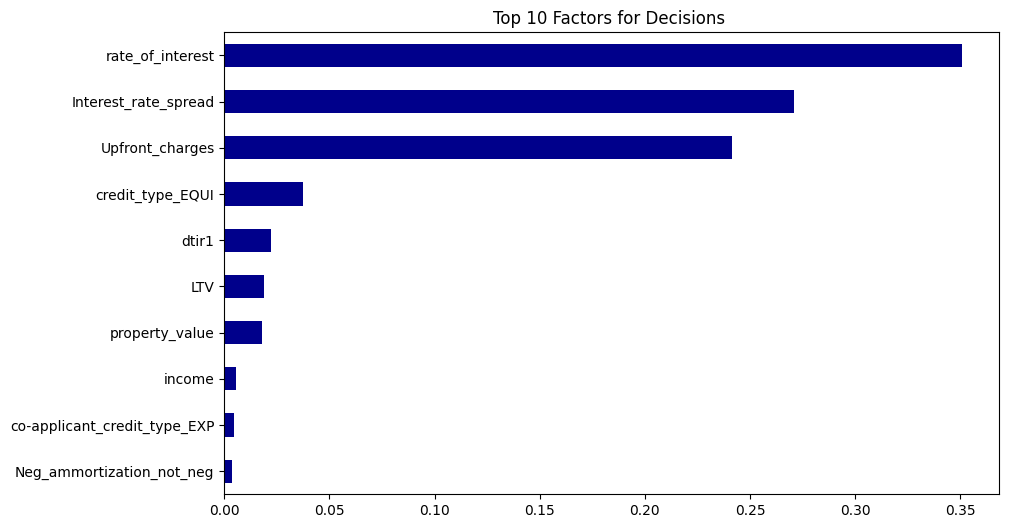

In [62]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
plt.figure(figsize=(10, 6))
importances.nlargest(10).plot(kind='barh', color='darkblue')
plt.title("Top 10 Factors for Decisions ")
plt.gca().invert_yaxis() 
plt.show()

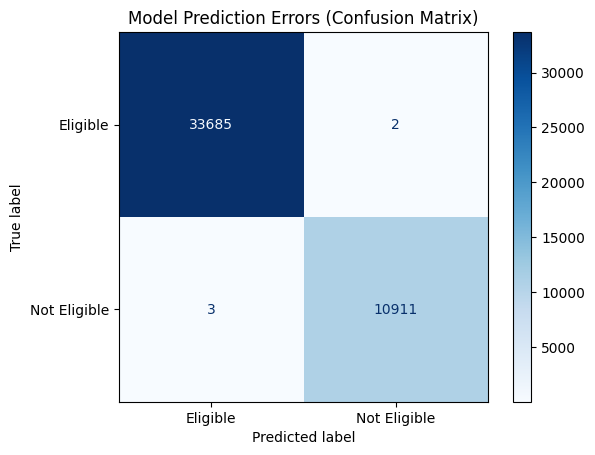

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Eligible', 'Not Eligible'])

disp.plot(cmap='Blues')
plt.title("Model Prediction Errors (Confusion Matrix)")
plt.show()

In [42]:
models = {
    "Linear SVM": model,
    "KNN": knn_model,
    "Random Forest": rf_model,
    "SVM RBF": svm_model
}

model_scores = {
    "Linear SVM": accuracy_score(y_test, y_pred_svm),
    "KNN": accuracy_score(y_test, y_pred_knn),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "SVM RBF": accuracy_score(y_test, y_pred_svm_rbf)
}

best_model_name = max(model_scores, key=model_scores.get)
final_model = models[best_model_name]

print(f"Scores: {model_scores}")
print(f"Using {best_model_name} for prediction (Accuracy: {model_scores[best_model_name]:.4f})")

Scores: {'Linear SVM': 0.8102284702136724, 'KNN': 0.7795565121858254, 'Random Forest': 0.9998878948902491, 'SVM RBF': 0.9386112419004058}
Using Random Forest for prediction (Accuracy: 0.9999)


In [65]:
input_data = pd.DataFrame(columns=X.columns)
input_data.loc[0] = 0  # Initialize all columns with 0

user_loan = float(input("Enter Loan Amount: "))
user_income = float(input("Enter Income: "))
user_credit = float(input("Enter Credit Score: "))

input_data['loan_amount'] = user_loan
input_data['income'] = user_income
input_data['Credit_Score'] = user_credit

Enter Loan Amount:  200000
Enter Income:  20000
Enter Credit Score:  800


### IF

In [69]:
if best_model_name == "Random Forest":
    prediction = svm_model.predict(input_data)
else:
    input_scaled = scaler.transform(input_data)
    prediction =svm_model.predict(input_scaled)

result = "Eligible for Loan" if prediction[0] == 0 else "Not Eligible for Loan"
print(f"Result: {result}")

Result: Eligible for Loan


### ELSE

In [67]:
default_template = X[y == 1].iloc[0:1].copy() 

user_loan = float(input("Enter Loan Amount: "))
user_income = float(input("Enter Income: "))
user_credit = float(input("Enter Credit Score: "))

default_template['loan_amount'] = user_loan
default_template['income'] = user_income
default_template['Credit_Score'] = user_credit

Enter Loan Amount:  900000
Enter Income:  2000
Enter Credit Score:  300


In [70]:
input_scaled = scaler.transform(default_template)
prediction = svm_model.predict(input_scaled)

result = "Eligible" if prediction[0] == 0 else "Not Eligible For Loan"
print(f"Result: {result}")

Result: Not Eligible For Loan
